# MDN architecture sweep results

Visualizes the 5×5 grid search over components × capacity:
- Heatmaps of OOS NLL per galaxy and overall
- Training curves to check convergence

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [2]:
df = pd.read_csv("mdn_sweep.csv")
with open("mdn_sweep.curves.json") as f:
    curves = json.load(f)

print(f"{len(df)} configurations")
df.head()

25 configurations


,capacity,n_layers,n_hidden,n_components,nll_MW,r2_MW,nll_NGC300,r2_NGC300,nll_ETG-vlM,r2_ETG-vlM,nll_ETG-lowM,r2_ETG-lowM,nll_ETG-medM,r2_ETG-medM,nll_ETG-hiM,r2_ETG-hiM,nll_mean,r2_mean
0,2x64,2,64,3,2.684499,0.074077,3.089807,0.032518,1.742635,0.374188,1.532302,0.262098,1.212643,0.600599,1.615099,0.393258,1.979497,0.289456
1,2x64,2,64,5,2.722175,0.074325,1.855340,0.029756,1.497255,0.378514,2.392033,0.261883,1.266672,0.597326,1.458170,0.407677,1.865274,0.291580
2,2x64,2,64,8,1.847943,0.062863,1.808388,0.027488,1.545322,0.385249,1.551597,0.261075,1.271227,0.594016,1.360828,0.391631,1.564217,0.287054
3,2x64,2,64,12,1.778196,0.074590,1.912675,0.012475,1.445316,0.377986,1.511248,0.260868,1.270849,0.589326,1.431067,0.399834,1.558225,0.285847
4,2x64,2,64,16,1.794702,0.074668,1.799529,0.024795,1.497605,0.382036,1.515960,0.261705,1.285884,0.596311,1.439364,0.406695,1.555507,0.291035


In [3]:
# Extract axis labels from the data
capacities = df["capacity"].unique()
components = df["n_components"].unique()
galaxy_cols = [c for c in df.columns if c.startswith("nll_") and c != "nll_mean"]
galaxy_names = [c.replace("nll_", "") for c in galaxy_cols]

print(f"Capacities: {list(capacities)}")
print(f"Components: {list(components)}")
print(f"Galaxies: {galaxy_names}")

Capacities: ['2x64', '3x64', '3x128', '5x128', '5x256']
Components: [np.int64(3), np.int64(5), np.int64(8), np.int64(12), np.int64(16)]
Galaxies: ['MW', 'NGC300', 'ETG-vlM', 'ETG-lowM', 'ETG-medM', 'ETG-hiM']


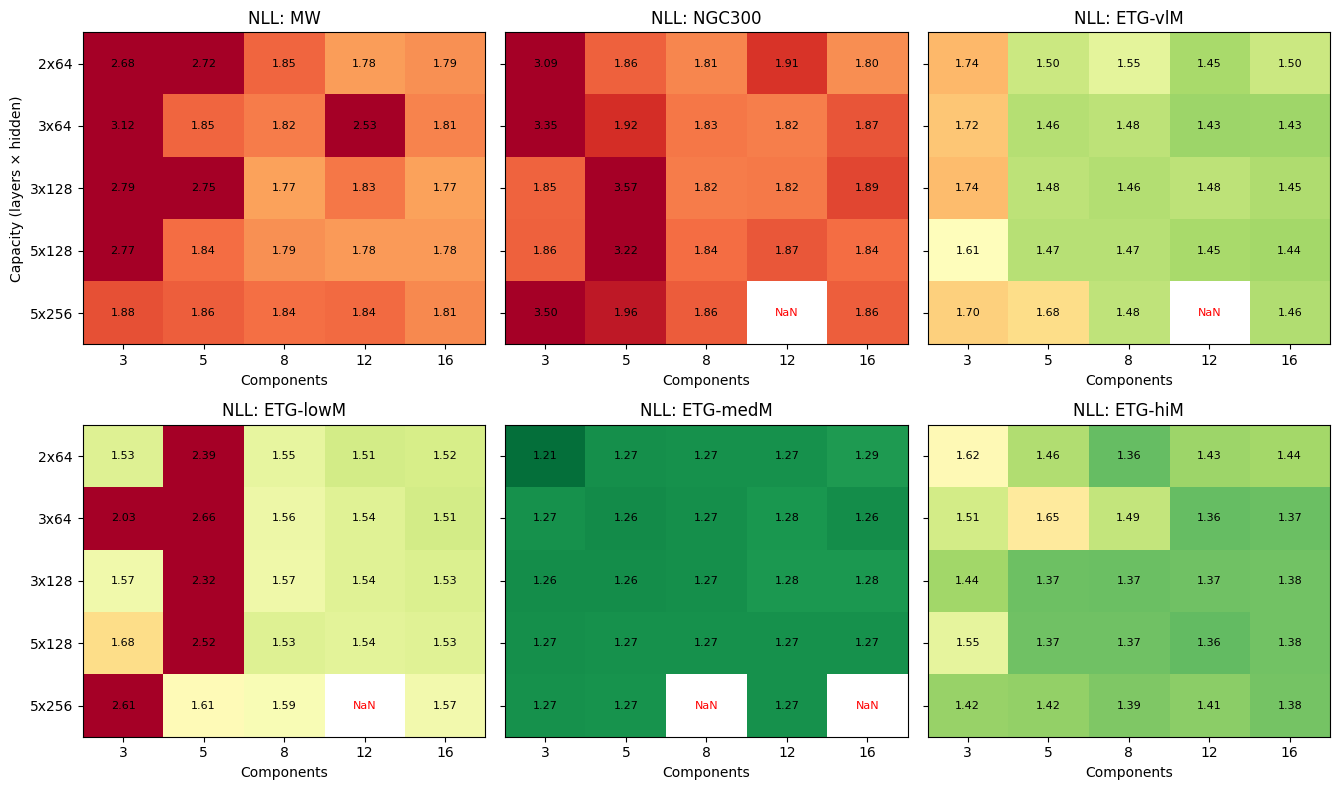

In [17]:
# NLL heatmaps: one per galaxy + overall mean
plot_cols = galaxy_cols + ["nll_mean"]
plot_titles = galaxy_names + ["Mean"]
n_plots = len(plot_cols)

fig, axes = plt.subplots(2, n_plots // 2, figsize=(4.5 * (n_plots // 2), 8), sharey=True)
axes = axes.flatten()

for ax, col, title in zip(axes, plot_cols, plot_titles):
    grid = np.full((len(capacities), len(components)), np.nan)
    for i, cap in enumerate(capacities):
        for j, comp in enumerate(components):
            row = df[(df["capacity"] == cap) & (df["n_components"] == comp)]
            if len(row) == 1:
                grid[i, j] = row[col].values[0]

    im = ax.imshow(grid, aspect="auto", cmap="RdYlGn_r", vmin=1.2, vmax=2.0)
    ax.set_xticks(range(len(components)))
    ax.set_xticklabels(components)
    ax.set_xlabel("Components")
    if ax == axes[0]:
        ax.set_yticks(range(len(capacities)))
        ax.set_yticklabels(capacities)
        ax.set_ylabel("Capacity (layers × hidden)")
    ax.set_title(f"NLL: {title}")

    # Annotate cells
    for i in range(len(capacities)):
        for j in range(len(components)):
            val = grid[i, j]
            if np.isfinite(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
            else:
                ax.text(j, i, "NaN", ha="center", va="center", fontsize=8, color="red")

plt.tight_layout()
plt.show()

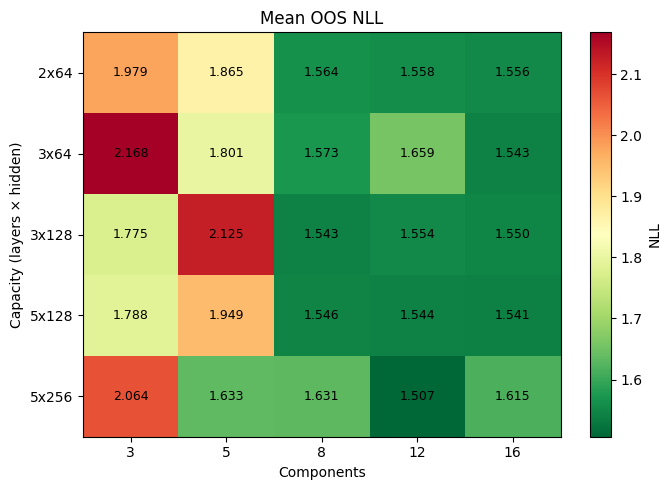

In [15]:
mean_nll_grid = np.full((len(capacities), len(components)), np.nan)

for i, capacity in enumerate(capacities):
    for j, n_component in enumerate(components):
        match = df[
            (df["capacity"] == capacity) &
            (df["n_components"] == n_component)
        ]
        if len(match) == 1:
            mean_nll_grid[i, j] = match["nll_mean"].iloc[0]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(mean_nll_grid, aspect="auto", cmap="RdYlGn_r")

ax.set_xticks(range(len(components)))
ax.set_xticklabels(components)
ax.set_xlabel("Components")

ax.set_yticks(range(len(capacities)))
ax.set_yticklabels(capacities)
ax.set_ylabel("Capacity (layers × hidden)")

ax.set_title("Mean OOS NLL")

for i in range(len(capacities)):
    for j in range(len(components)):
        value = mean_nll_grid[i, j]
        label = f"{value:.3f}" if np.isfinite(value) else "NaN"
        color = "black" if np.isfinite(value) else "red"
        ax.text(j, i, label, ha="center", va="center", fontsize=9, color=color)

fig.colorbar(im, ax=ax, label="NLL")
plt.tight_layout()
plt.show()

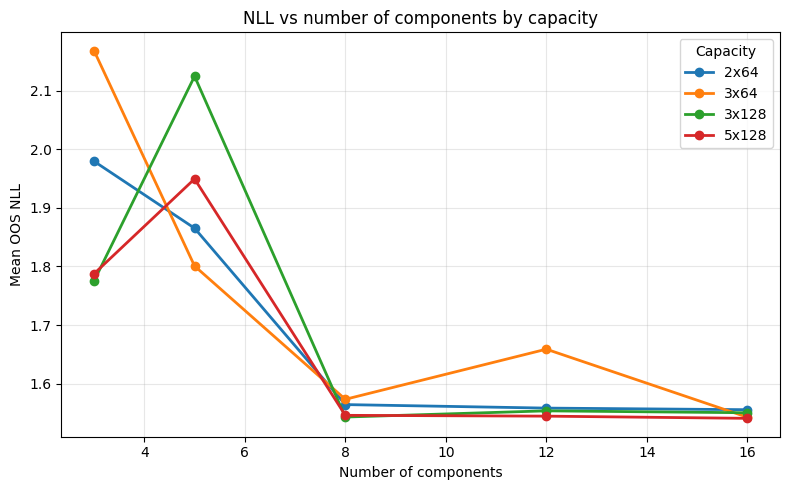

In [16]:
selected_capacities = ["2x64", "3x64", "3x128", "5x128"]

fig, ax = plt.subplots(figsize=(8, 5))

for capacity_name in selected_capacities:
    subset = (
        df[df["capacity"] == capacity_name]
        .sort_values("n_components")
    )
    ax.plot(
        subset["n_components"],
        subset["nll_mean"],
        marker="o",
        linewidth=2,
        label=capacity_name,
    )

ax.set_xlabel("Number of components")
ax.set_ylabel("Mean OOS NLL")
ax.set_title("NLL vs number of components by capacity")
ax.legend(title="Capacity")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

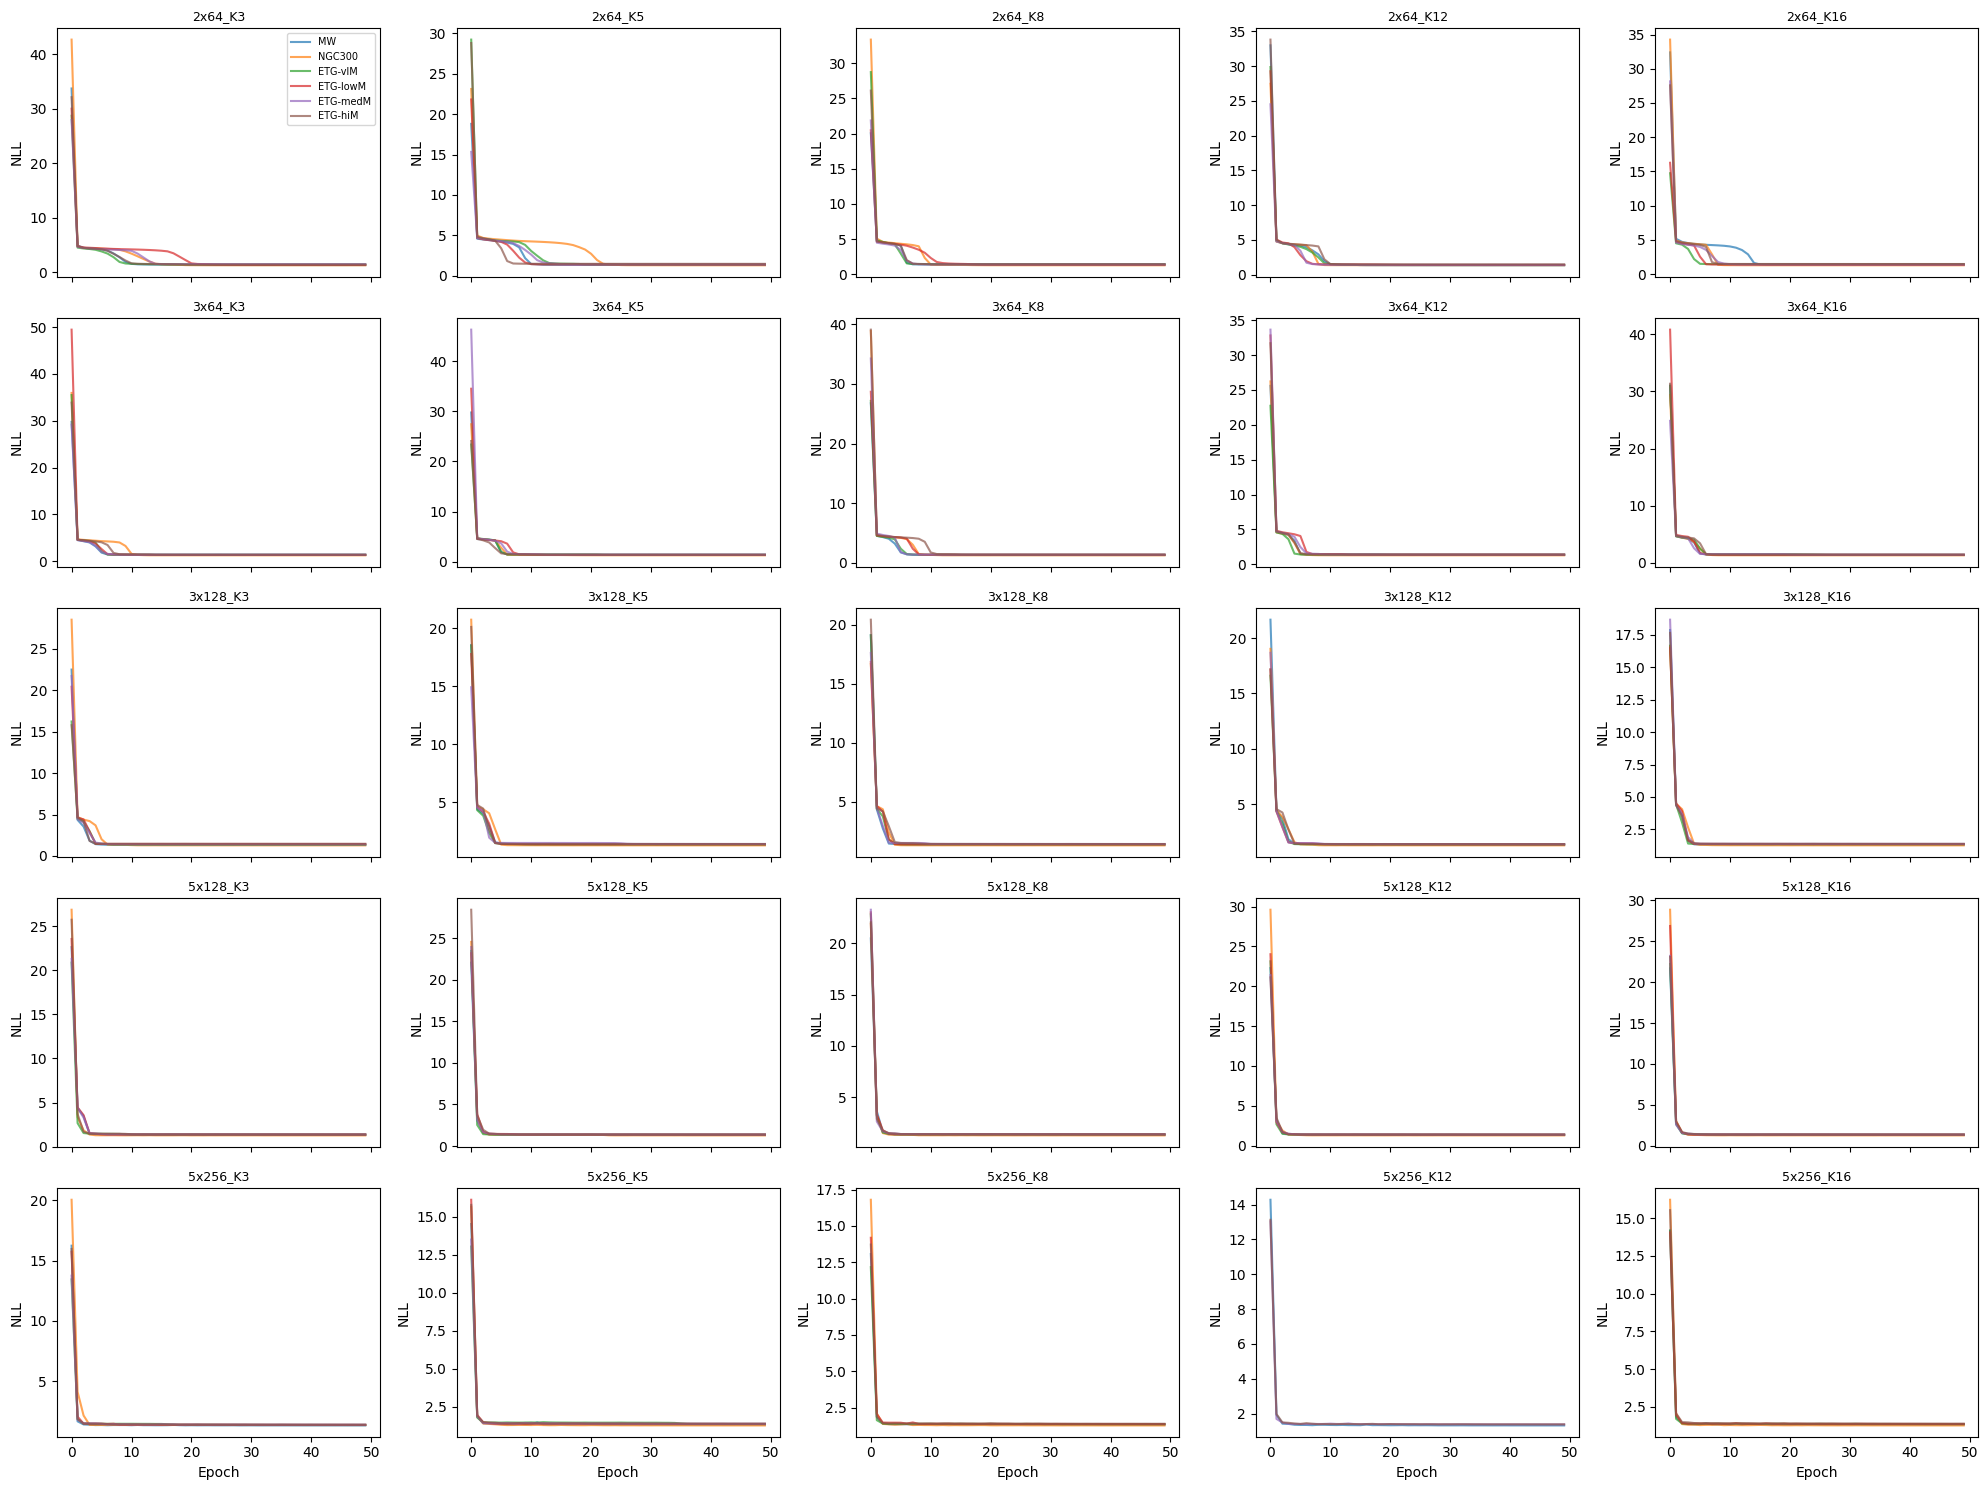

In [18]:
# Training curves: one subplot per config, colored by held-out galaxy
n_configs = len(curves)
n_cols = 5
n_rows = int(np.ceil(n_configs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True)
axes = axes.flatten()

for idx, (config_name, fold_curves) in enumerate(curves.items()):
    ax = axes[idx]
    for gal_name, losses in fold_curves.items():
        ax.plot(losses, alpha=0.7, label=gal_name)
    ax.set_title(config_name, fontsize=9)
    ax.set_ylabel("NLL")

# Hide unused subplots
for idx in range(n_configs, len(axes)):
    axes[idx].set_visible(False)

# Shared x-label and legend
for ax in axes[n_configs - n_cols:n_configs]:
    ax.set_xlabel("Epoch")
axes[0].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()